# Homework 2.2 — Bootstrap simulation of treatment effects

## tl;dr

Using the 10,000 supplied observations and 100,000 bootstrap resamples
(seed 42), the quiz choices are **Q3: D, Q4: C, Q5: A**.

| Quantity | Computed value | Closest choice |
|---|---:|---|
| Observed treated-minus-untreated mean Y | 2.920717 | Q3 D: 2.921 |
| Bootstrap variance of that difference | 0.031615 | Q4 C: 0.03274 |
| Skewness of bootstrapped adjusted X coefficients | 0.042796 | Q5 A: 0.04850 |

The adjusted model is `Y ~ intercept + X + Z`. Bootstrap variance and
skewness depend on the seed and number of resamples; the choices above
are the closest values, not exact expected simulation outputs.

## Context & Methods

Source: `../homework_2.2.csv` relative to this notebook. `X` is the
binary treatment, `Y` is the outcome, and `Z` is the available covariate.
For Q3–Q4, estimate the unadjusted effect as
$\overline{Y}_{X=1}-\overline{Y}_{X=0}$. For Q5, interpret the regression
as $Y=\alpha+\tau X+\gamma Z+\varepsilon$, and compute skewness across
the bootstrapped estimates of $\tau$.

Each bootstrap sample draws 10,000 complete rows with replacement.
Keep X, Y, and Z together. Fit the regression again in each sample;
skewness refers to the distribution of treatment coefficients, not
the outcomes, residuals, or three coefficients from a single fit.

### Key Assumptions

Rows are treated as independent observations. Use the full sample size
per resample, sample variance (`ddof=1`), and SciPy's default moment
skewness (`bias=True`). Neither bootstrap resampling nor linear
adjustment guarantees that confounding has been removed.

SciPy defines skewness as $m_3/m_2^{3/2}$: zero indicates no third-moment
asymmetry and positive values indicate right skew.
[SciPy skew documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html).

Setup if needed: `%pip install numpy pandas matplotlib scipy scikit-learn`.
Keep the CSV in the project folder above `Homework Code`.

## Data

### 1. Setup and source checks

In [1]:
from pathlib import Path
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.linear_model import LinearRegression

pd.set_option('display.precision', 6)
plt.rcParams.update({
    'figure.figsize': (9, 4.8), 'figure.dpi': 110,
    'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E5E7EB', 'axes.axisbelow': True,
    'text.color': '#1F2937', 'axes.labelcolor': '#1F2937',
})
BLUE, GOLD, DARK = '#2563EB', '#B7791F', '#374151'

def locate_csv(filename):
    # Works when launched from either Homework Code or the project folder.
    candidates = [Path.cwd() / filename, Path.cwd().parent / filename]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f'Cannot find {filename}. Run from the project folder or Homework Code.'
    )

def show_table(frame, formats=None):
    display(frame.style.hide(axis='index').format(formats or {}, na_rep='—'))

from scipy.stats import skew

N_BOOTSTRAPS = 100_000
RANDOM_SEED = 42
BATCH_SIZE = 100

In [2]:
DATA_PATH = locate_csv('homework_2.2.csv')
data = pd.read_csv(DATA_PATH)
required = ['X', 'Y', 'Z']
if not set(required).issubset(data.columns):
    raise ValueError(f'Required columns: {required}')
if not all(pd.api.types.is_numeric_dtype(data[c]) for c in required):
    raise TypeError('X, Y, and Z must be numeric.')
if not np.isfinite(data[required].to_numpy()).all():
    raise ValueError('Data contain missing or infinite values.')
if set(data['X'].unique()) != {0, 1}:
    raise ValueError('Expected both treatment levels, 0 and 1.')
print(f'Source: {DATA_PATH.name}; rows: {len(data):,}; missing values: 0')
print('SHA-256:', hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())
display(data.head())

Source: homework_2.2.csv; rows: 10,000; missing values: 0
SHA-256: e8808951d6c86cf37a58b3800f6507b7d3de2adc9132328363fd8e2d3ff8fae3


,X,Y,Z
0,0,1.182435,-0.725820
1,0,2.714474,0.563476
2,0,0.077612,-0.435632
3,0,-0.154449,-0.104553
4,0,22.298992,-2.321273


### 2. Summarize treated and untreated outcomes

In [3]:
group_summary = data.groupby('X').agg(
    observations=('Y', 'size'), mean_Y=('Y', 'mean'),
    variance_Y=('Y', 'var'), mean_Z=('Z', 'mean')
).reset_index()
show_table(group_summary, {
    'mean_Y': '{:.6f}', 'variance_Y': '{:.6f}', 'mean_Z': '{:.6f}'
})

X,observations,mean_Y,variance_Y,mean_Z
0,8028,4.922040,52.569554,-0.010159
1,1972,7.842757,49.948966,0.037857


## Results

### 3. Q3 — observed difference in means and adjusted regression

In [4]:
x = data['X'].to_numpy(dtype=float)
y = data['Y'].to_numpy(dtype=float)
z = data['Z'].to_numpy(dtype=float)
n = len(data)
treated_mean = y[x == 1].mean()
untreated_mean = y[x == 0].mean()
observed_naive_effect = treated_mean - untreated_mean

regression = LinearRegression(fit_intercept=True).fit(data[['X', 'Z']], y)
observed_adjusted_effect = regression.coef_[0]
show_table(pd.DataFrame({
    'Estimate': ['Treated mean Y', 'Untreated mean Y', 'Difference in means (Q3)',
                 'Adjusted X coefficient', 'Z coefficient', 'Regression intercept'],
    'Value': [treated_mean, untreated_mean, observed_naive_effect,
              observed_adjusted_effect, regression.coef_[1], regression.intercept_],
}), {'Value': '{:.6f}'})

Estimate,Value
Treated mean Y,7.842757
Untreated mean Y,4.922040
Difference in means (Q3),2.920717
Adjusted X coefficient,2.818696
Z coefficient,2.124724
Regression intercept,4.943624


### 4. Bootstrap both estimators

The code below uses centered sums to solve the two-predictor OLS
regression with an intercept. This is the same fit as
`LinearRegression(fit_intercept=True)` and avoids creating 100,000
estimator objects. The first five resampled fits are checked against
scikit-learn. Batches limit memory use without changing the sample size.

For centered sums $S_{ab}=\sum_i(a_i-\bar a)(b_i-\bar b)$,
$$\widehat{\tau}=
\frac{S_{xy}S_{zz}-S_{zy}S_{xz}}{S_{xx}S_{zz}-S_{xz}^2}.$$

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
bootstrap_naive = np.empty(N_BOOTSTRAPS)
bootstrap_adjusted = np.empty(N_BOOTSTRAPS)

for start in range(0, N_BOOTSTRAPS, BATCH_SIZE):
    size = min(BATCH_SIZE, N_BOOTSTRAPS - start)
    indices = rng.integers(0, n, size=(size, n))
    xb, yb, zb = x[indices], y[indices], z[indices]
    sx, sy, sz = xb.sum(axis=1), yb.sum(axis=1), zb.sum(axis=1)
    sxy = (xb * yb).sum(axis=1)
    sxz = (xb * zb).sum(axis=1)
    szy = (zb * yb).sum(axis=1)
    szz = (zb * zb).sum(axis=1)
    if np.any((sx == 0) | (sx == n)):
        raise ValueError('A resample has only one treatment level.')

    # X is binary: sum(X * Y) is the total outcome in the treated group.
    naive_batch = sxy / sx - (sy - sxy) / (n - sx)
    cxx = sx - sx * sx / n
    cxz = sxz - sx * sz / n
    czz = szz - sz * sz / n
    cxy = sxy - sx * sy / n
    czy = szy - sz * sy / n
    determinant = cxx * czz - cxz * cxz
    if np.any(determinant <= 0):
        raise ValueError('A bootstrap design is rank deficient.')
    adjusted_batch = (cxy * czz - czy * cxz) / determinant

    if start == 0:
        for j in range(min(5, size)):
            sample = data.iloc[indices[j]]
            reference = LinearRegression().fit(sample[['X', 'Z']], sample['Y'])
            np.testing.assert_allclose(adjusted_batch[j], reference.coef_[0],
                                       rtol=1e-10, atol=1e-10)
            direct_difference = (sample.loc[sample.X == 1, 'Y'].mean()
                                 - sample.loc[sample.X == 0, 'Y'].mean())
            np.testing.assert_allclose(naive_batch[j], direct_difference, atol=1e-10)

    bootstrap_naive[start:start + size] = naive_batch
    bootstrap_adjusted[start:start + size] = adjusted_batch

assert np.isfinite(bootstrap_naive).all() and np.isfinite(bootstrap_adjusted).all()
print(f'Completed {N_BOOTSTRAPS:,} full-row bootstrap resamples (seed {RANDOM_SEED}).')
print('First five regression fits and differences agree with direct calculations.')

Completed 100,000 full-row bootstrap resamples (seed 42).
First five regression fits and differences agree with direct calculations.


### 5. Q4–Q5 — variance and skewness

In [6]:
naive_bootstrap_variance = np.var(bootstrap_naive, ddof=1)
regression_bootstrap_skewness = skew(bootstrap_adjusted, bias=True)
bootstrap_summary = pd.DataFrame({
    'Estimator': ['Unadjusted difference in means', 'Adjusted treatment coefficient'],
    'Observed': [observed_naive_effect, observed_adjusted_effect],
    'Bootstrap mean': [bootstrap_naive.mean(), bootstrap_adjusted.mean()],
    'Bootstrap variance': [naive_bootstrap_variance, bootstrap_adjusted.var(ddof=1)],
    'Skewness': [skew(bootstrap_naive), regression_bootstrap_skewness],
})
show_table(bootstrap_summary, {c: '{:.6f}' for c in bootstrap_summary.columns[1:]})

# A separate, analytic approximation to the difference-in-means variance.
approximate_variance = (y[x == 1].var(ddof=1) / sum(x == 1)
                        + y[x == 0].var(ddof=1) / sum(x == 0))
print(f'Analytic variance approximation: {approximate_variance:.6f}')
print(f'Bootstrap standard error: {np.sqrt(naive_bootstrap_variance):.6f}')

Estimator,Observed,Bootstrap mean,Bootstrap variance,Skewness
Unadjusted difference in means,2.920717,2.920500,0.031615,0.049014
Adjusted treatment coefficient,2.818696,2.818479,0.028361,0.042796


Analytic variance approximation: 0.031877
Bootstrap standard error: 0.177807


Variance is the squared spread of the bootstrap estimates; standard
error is its square root. Q4 asks for the variance. Q5 uses the
skewness of the adjusted treatment estimates across resamples.

### 6. Inspect the bootstrap distributions

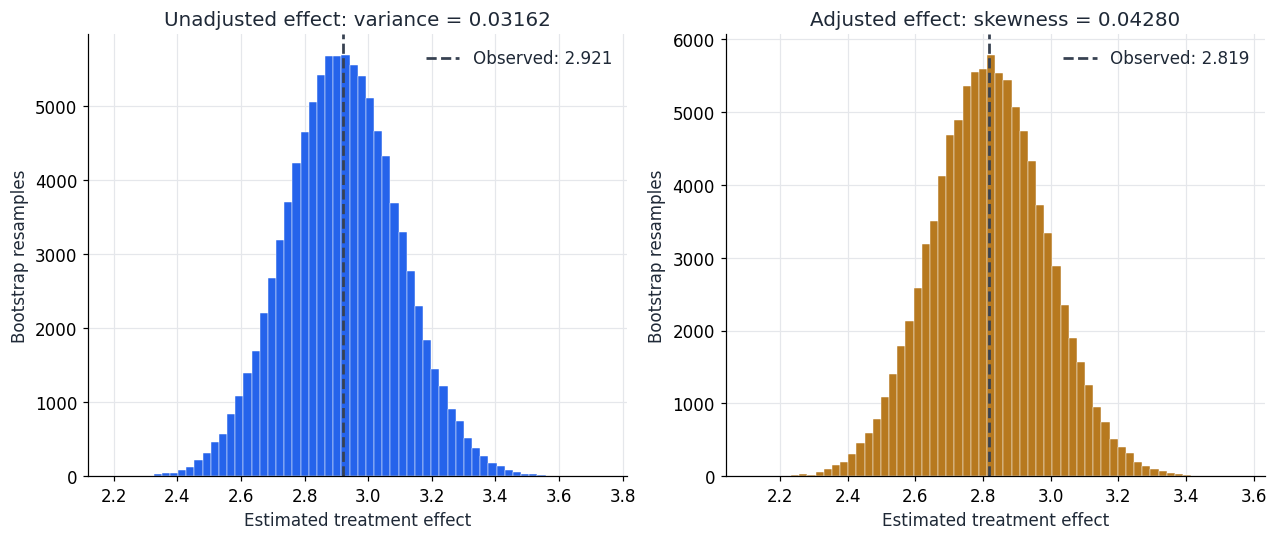

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), layout='constrained')
settings = [
    (axes[0], bootstrap_naive, observed_naive_effect, BLUE,
     f'Unadjusted effect: variance = {naive_bootstrap_variance:.5f}'),
    (axes[1], bootstrap_adjusted, observed_adjusted_effect, GOLD,
     f'Adjusted effect: skewness = {regression_bootstrap_skewness:.5f}'),
]
for ax, values, original, color, title in settings:
    ax.hist(values, bins=60, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(original, color=DARK, linestyle='--', linewidth=1.8,
               label=f'Observed: {original:.3f}')
    ax.set(title=title, xlabel='Estimated treatment effect', ylabel='Bootstrap resamples')
    ax.legend(frameon=False)
plt.show()

The adjusted bootstrap distribution has slight positive skewness and
is approximately bell-shaped. Each histogram contains 100,000
estimates. Its horizontal spread describes sampling variability,
not whether the estimator has removed confounding.

### 7. Check Monte Carlo stability

In [8]:
checkpoints = [b for b in [1_000, 10_000, 20_000, 50_000, 100_000] if b <= N_BOOTSTRAPS]
if N_BOOTSTRAPS not in checkpoints:
    checkpoints.append(N_BOOTSTRAPS)
convergence = pd.DataFrame({
    'Resamples': checkpoints,
    'Unadjusted variance': [np.var(bootstrap_naive[:b], ddof=1) for b in checkpoints],
    'Adjusted coefficient skewness': [skew(bootstrap_adjusted[:b]) for b in checkpoints],
})
show_table(convergence, {
    'Resamples': '{:,}', 'Unadjusted variance': '{:.6f}',
    'Adjusted coefficient skewness': '{:.6f}'
})

Resamples,Unadjusted variance,Adjusted coefficient skewness
"1,000",0.031845,0.137284
"10,000",0.031618,0.043981
"20,000",0.031671,0.058089
"50,000",0.031806,0.044045
"100,000",0.031615,0.042796


Skewness is sensitive to the number of simulated estimates: with
only 1,000 resamples this seed gives about 0.137, while 100,000 gives
about 0.043. The quiz supplies no seed or simulation count, so use the
closest option after a sufficiently large run.

### 8. Map the computed results to the answer choices

In [9]:
choices = {
    'Q3': {'A': 8.031, 'B': 5.149, 'C': 12.831, 'D': 2.921},
    'Q4': {'A': 0.002388, 'B': 0.001822, 'C': 0.03274, 'D': 0.1280},
    'Q5': {'A': 0.04850, 'B': 0.3223, 'C': 0.2315, 'D': 0.09812},
}
computed = {'Q3': observed_naive_effect, 'Q4': naive_bootstrap_variance,
            'Q5': regression_bootstrap_skewness}
answers = []
for question, value in computed.items():
    option = min(choices[question], key=lambda key: abs(choices[question][key] - value))
    answers.append({'Question': question, 'Computed': value,
                    'Option': option, 'Choice value': choices[question][option]})
show_table(pd.DataFrame(answers), {'Computed': '{:.6f}', 'Choice value': '{:.6f}'})

Question,Computed,Option,Choice value
Q3,2.920717,D,2.921000
Q4,0.031615,C,0.032740
Q5,0.042796,A,0.048500


## Takeaways

- **Q3: D (2.921)** — the observed difference is **2.920717**;
  its bootstrap mean is approximately **2.920500**.
- **Q4: C (0.03274)** — the simulated variance is **0.031615**.
- **Q5: A (0.04850)** — skewness of the bootstrapped X coefficient
  from `Y ~ intercept + X + Z` is **0.042796**.

These bootstrap results quantify variation around the fitted
estimators. The model specification and available covariates still
determine whether a causal interpretation is warranted.

### Reproducibility

In [10]:
print('Python', platform.python_version())
for package in ['numpy', 'pandas', 'matplotlib', 'scipy', 'scikit-learn']:
    print(package, importlib.metadata.version(package))
print(f'Bootstrap: B={N_BOOTSTRAPS}, seed={RANDOM_SEED}, sample size={n}, batch={BATCH_SIZE}')

Python 3.13.5
numpy 2.4.1
pandas 3.0.0
matplotlib 3.10.8
scipy 1.17.0
scikit-learn 1.8.0
Bootstrap: B=100000, seed=42, sample size=10000, batch=100
